# Figure 6: Change-Point Summary

Translation of `Figure06_cpSummary.m`

## What this notebook does

Characterises how participants adjust their decision bounds in response to a **change point (CP)**
in the generative process. In CP trials the SNR shifts mid-block at a random time; the optimal
response is to increase or decrease the bound to maximise reward rate at the new SNR.

**3-row, 2-column figure layout** (columns = LowHigh / HighLow CP directions):

- **Row 1 — Example RR gradient**: One example subject's RR vs. bound curve, with markers at
  the pre-CP bound (blue), optimal bound (red), and post-CP bound (green).
- **Row 2 — Gradient vs. bound change**: Scatter of per-subject RR gradient (slope toward the
  optimal bound) vs. actual post-CP − pre-CP bound change. Spearman correlation in the title.
- **Row 3 — Pre vs. post-CP bound**: Scatter of bound before CP vs. bound in the corresponding
  stable-SNR condition (Low vs. Low, HighLow vs. HighLow), with Wilcoxon p-value.

## Data requirements

This figure requires two pre-computed data files (generated by the MATLAB pipeline):

1. **`boundSummaries_wCP.mat`**: Per-subject bound summaries for the CP task.
   Fields: `LowHigh` (n_subjects × 2: [pre-CP bound, post-CP bound] for Low→High transitions),
   `HighLow`, `Low`, `High`, `CPLowHigh` (CP times per subject), `CPHighLow`.

2. **`RRMats.mat`**: Reward-rate matrices from `getPigeon_RRMatrix('blockType', 'CP')`.
   Contains `pmats` — a cell array of two matrices: `pmats{1}` for LowHigh, `pmats{2}` for
   HighLow. Each has shape (n_pre_bounds × n_post_bounds × n_cp_times).

## Implementation status

The CP task data pipeline (`get_data_table(task_type='CP')`) and the corresponding reward-rate
simulation (`getPigeon_RRMatrix` with `blockType='CP'`) are not yet translated from MATLAB to
Python. The plotting code below is complete and will run once the required `.mat` files are
available.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import scipy.io
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pigeon.pathDefaults import BOUND_SUMMARIES_FILE, RR_MATS_FILE, FIGURES_DIR

# Bound grid used by getPigeon_RRMatrix for CP (matches MATLAB: 0.01:0.05:0.8)
BOUNDS = np.arange(0.01, 0.81, 0.05)

## Load pre-computed data

Loads the two required `.mat` files. Raises `FileNotFoundError` with a clear message if either
is missing, since the Python CP data pipeline is not yet implemented.

**Data included** (when files are available): All subjects from the CP task; all unique CP times.

**Data excluded**: Subjects with non-finite pre- or post-CP bounds (`isfinite` filter applied
during plotting).

In [2]:
if not os.path.exists(BOUND_SUMMARIES_FILE):
    raise FileNotFoundError(
        f'{BOUND_SUMMARIES_FILE!r} not found.\n'
        'This file is generated by the MATLAB CP task analysis pipeline.\n'
        'The Python CP task pipeline (get_data_table with task_type="CP") '
        'is not yet implemented.'
    )

if not os.path.exists(RR_MATS_FILE):
    raise FileNotFoundError(
        f'{RR_MATS_FILE!r} not found.\n'
        'This file is generated by getPigeon_RRMatrix.m with blockType="CP".'
    )

# Load bound summaries (MATLAB struct with fields LowHigh, HighLow, Low, High,
# CPLowHigh, CPHighLow)
mat = scipy.io.loadmat(BOUND_SUMMARIES_FILE, squeeze_me=True, struct_as_record=False)
bs  = mat['boundSummaries']   # MATLAB struct

lh_bounds  = bs.LowHigh    # (n_subjects, 2): col 0 = pre-CP, col 1 = post-CP
hl_bounds  = bs.HighLow
lo_bounds  = bs.Low        # stable Low blocks: (n_subjects, 2)
hi_bounds  = bs.High       # stable High blocks
cp_lh      = bs.CPLowHigh  # (n_subjects,): CP time for LowHigh trials
cp_hl      = bs.CPHighLow

# Load RR matrices: pmats is a 2-element cell → Python list of arrays
# pmats[0] = LowHigh RR matrix (n_bounds × n_bounds × n_cp_times)
# pmats[1] = HighLow RR matrix
rr_mat      = scipy.io.loadmat(RR_MATS_FILE, squeeze_me=True, struct_as_record=False)
pmats       = list(rr_mat['pmats'].flat)  # convert MATLAB cell to Python list

cp_times    = [np.unique(cp_lh), np.unique(cp_hl)]
titles      = ['LowHigh', 'HighLow']

print(f'LowHigh:  median [IQR] CP time = '
      f'{np.percentile(cp_lh, 50):.1f} [{np.percentile(cp_lh, 25):.1f} '
      f'{np.percentile(cp_lh, 75):.1f}]')
print(f'HighLow:  median [IQR] CP time = '
      f'{np.percentile(cp_hl, 50):.1f} [{np.percentile(cp_hl, 25):.1f} '
      f'{np.percentile(cp_hl, 75):.1f}]')

LowHigh:  median [IQR] CP time = 9.5 [8.0 15.0]
HighLow:  median [IQR] CP time = 8.0 [6.8 11.0]


## Row 1: Reward-rate functions

For each CP direction, plots the simulated RR vs. bound curve at the median CP time, for two
representative bound values (pre-CP SNR bound and post-CP optimum). Matches MATLAB's `inds = [3 5]`
(1-indexed), i.e. bounds at index 2 and 4 (0-indexed) in `BOUNDS`.

## Rows 1–2: Example RR gradient and gradient vs. bound change

**Row 1**: One example subject's RR vs. bound curve at the time of their CP, with markers at
the pre-CP bound (blue cross), optimal bound (red cross), and post-CP bound (green cross).

**Row 2**: Per-subject scatter of RR gradient (slope from pre-CP bound toward optimal bound,
in coins/step per bound unit) vs. actual bound change (post-CP − pre-CP). Spearman correlation.

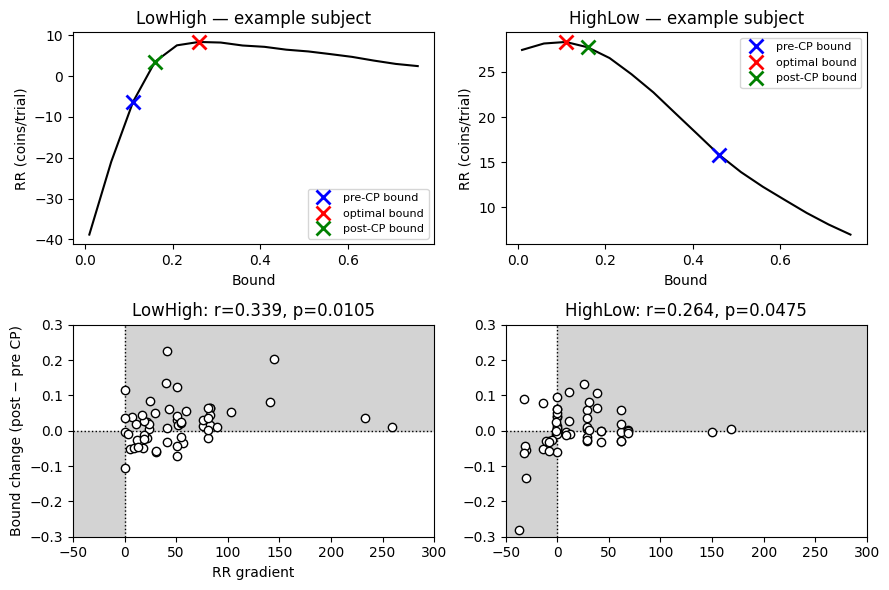

In [4]:
# MATLAB example subject indices (1-indexed): tt=1 → pp=53, tt=2 → pp=52
EXAMPLE_SUBJECTS = {0: 52, 1: 51}   # 0-indexed

fig_r23, axs_r23 = plt.subplots(2, 2, figsize=(9, 6))

for tt in range(2):
    rmat = pmats[tt]

    xs = lh_bounds[:, 0] if tt == 0 else hl_bounds[:, 0]   # pre-CP bounds
    ys = lh_bounds[:, 1] if tt == 0 else hl_bounds[:, 1]   # post-CP bounds
    cpt = cp_lh if tt == 0 else cp_hl
    Lg  = np.isfinite(xs) & np.isfinite(ys)

    grads = np.full(len(cpt), np.nan)

    for pp in range(len(cpt)):
        if not Lg[pp]:
            continue

        # Find which cp_times slice corresponds to this subject's CP time
        cp_idx_arr = np.where(cp_times[tt] == cpt[pp])[0]
        if len(cp_idx_arr) == 0:
            continue
        cp_idx = int(cp_idx_arr[0])

        # RR vs. post-CP bound for this subject's pre-CP bound (raw, no smoothing)
        prei = int(np.searchsorted(BOUNDS, xs[pp], side='right')) - 1
        prei = np.clip(prei, 0, len(BOUNDS) - 1)
        rrs  = rmat[prei, :, cp_idx]

        # Find max on raw rrs (matching MATLAB: maxi = find(rrs == max(rrs), 1))
        maxi = int(np.nanargmax(rrs))

        # RR gradient: slope from pre-CP bound toward optimal bound (on raw rrs)
        if maxi == prei:
            grads[pp] = 0.0
        else:
            grads[pp] = (rrs[maxi] - rrs[prei]) / (BOUNDS[maxi] - BOUNDS[prei])

        # Row 2: example subject's RR curve — smooth only for display
        if pp == EXAMPLE_SUBJECTS[tt]:
            kernel  = np.ones(3) / 3
            rrs_sm  = np.convolve(rrs, kernel, mode='same')
            rrs_sm[[0, -1]] = rrs[[0, -1]]

            ax2 = axs_r23[0, tt]
            ax2.cla()
            ax2.plot(BOUNDS, rrs_sm, 'k-')
            ax2.plot(BOUNDS[prei], rrs_sm[prei], 'bx', markersize=10, markeredgewidth=2,
                     label='pre-CP bound')
            ax2.plot(BOUNDS[maxi], rrs_sm[maxi], 'rx', markersize=10, markeredgewidth=2,
                     label='optimal bound')
            posti = int(np.searchsorted(BOUNDS, ys[pp], side='right')) - 1
            posti = np.clip(posti, 0, len(BOUNDS) - 1)
            ax2.plot(BOUNDS[posti], rrs_sm[posti], 'gx', markersize=10, markeredgewidth=2,
                     label='post-CP bound')
            ax2.set_xlabel('Bound')
            ax2.set_ylabel('RR (coins/trial)')
            ax2.set_title(f'{titles[tt]} — example subject')
            ax2.legend(fontsize=8)

    # Row 3: gradient vs. bound change
    ax3 = axs_r23[1, tt]
    ax3.set_xlim(-50, 300)
    ax3.set_ylim(-0.3, 0.3)
    # Light gray shading for lower-left and upper-right quadrants
    ax3.fill_between([-50, 0], [-0.3, -0.3], [0, 0], color='lightgray', zorder=0)
    ax3.fill_between([0, 300], [0, 0], [0.3, 0.3], color='lightgray', zorder=0)
    ax3.axhline(0, color='k', linestyle=':', linewidth=1)
    ax3.axvline(0, color='k', linestyle=':', linewidth=1)
    ax3.plot(grads[Lg], ys[Lg] - xs[Lg], 'ko', markerfacecolor='white')

    r, p = scipy.stats.spearmanr(grads[Lg], ys[Lg] - xs[Lg])
    ax3.set_title(f'{titles[tt]}: r={r:.3f}, p={p:.4f}')
    if tt == 0:
        ax3.set_xlabel('RR gradient')
        ax3.set_ylabel('Bound change (post − pre CP)')

plt.tight_layout()
plt.show()

## Row 3: Bound comparison across CP directions and stable conditions

Left panel (CP trials): LowHigh bound vs. HighLow bound — compares the bound used in
the two opposite CP directions.

Right panel (no-CP trials): Low bound vs. High bound — compares bounds in the two
stable SNR conditions. Wilcoxon signed-rank test p-value in each title.

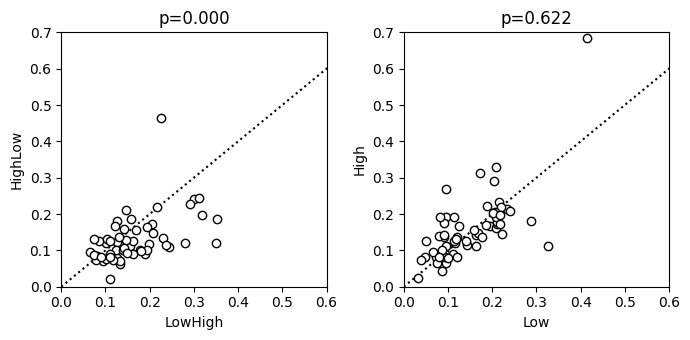

In [5]:
fig_r4, axs_r4 = plt.subplots(1, 2, figsize=(7, 3.5))

# MATLAB tags = {'LowHigh', 'HighLow'; 'Low', 'High'}
# tt=1 (left):  xs = LowHigh(:,2), ys = HighLow(:,1)  → CP trials
#   LowHigh(:,2) = post-CP bound (High-SNR period)
#   HighLow(:,1) = pre-CP bound  (High-SNR period)
#   Both are High-SNR environment bounds; LowHigh > HighLow (p<0.001)
# tt=2 (right): xs = Low(:,1),     ys = High(:,1)      → stable trials
compare_pairs = [
    (lh_bounds[:, 1], hl_bounds[:, 0], 'LowHigh', 'HighLow'),
    (lo_bounds[:, 0], hi_bounds[:, 0], 'Low',     'High'),
]

for ax, (xs, ys, xlabel, ylabel) in zip(axs_r4, compare_pairs):
    Lg = np.isfinite(xs) & np.isfinite(ys)
    ax.plot([0, 0.8], [0, 0.8], 'k:')
    ax.plot(xs[Lg], ys[Lg], 'ko', markerfacecolor='white')
    _, p = scipy.stats.wilcoxon(xs[Lg], ys[Lg])
    ax.set_title(f'p={p:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

## Formatted figure

Reproduces rows 1–3 at publication dimensions:

- **Width**: 8.5 cm (1 JNeurosci column)
- **Row heights**: [2, 4, 4] cm; vertical separation 2.0 cm; horizontal 1.0 cm
- **Font size**: 12 pt
- Saves to `Figure06_formatted.pdf`.

In [ ]:
# ── Publication layout matching MATLAB getPLOT_axes(6, 8.5, [2,4,4], {2,2,2}, 2.0, 1.0) ──
CM    = 1 / 2.54
WID   = 8.5
HTS   = [2.0, 4.0, 4.0]
PSH   = 2.0
PSW   = 1.0
FS    = 12

fig_h = sum(HTS) + PSH * (len(HTS) - 1)   # 2+4+4 + 2*2 = 14 cm
panel_w = (WID - PSW) / 2                  # 3.75 cm

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))

gs = gridspec.GridSpec(
    3, 2, figure=fig_fmt,
    height_ratios=HTS,
    hspace=PSH / np.mean(HTS),
    wspace=PSW / panel_w,
    left=0, right=1, bottom=0, top=1,
)
axs_fmt = np.array([[fig_fmt.add_subplot(gs[r, c]) for c in range(2)] for r in range(3)])
plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

# Rows 1–2: gradients computed on raw rrs; smoothing only for example subject display
for tt in range(2):
    rmat = pmats[tt]
    xs = lh_bounds[:, 0] if tt == 0 else hl_bounds[:, 0]
    ys = lh_bounds[:, 1] if tt == 0 else hl_bounds[:, 1]
    cpt = cp_lh if tt == 0 else cp_hl
    Lg  = np.isfinite(xs) & np.isfinite(ys)
    grads = np.full(len(cpt), np.nan)

    for pp in range(len(cpt)):
        if not Lg[pp]:
            continue
        cp_idx_arr = np.where(cp_times[tt] == cpt[pp])[0]
        if not len(cp_idx_arr):
            continue
        prei = int(np.clip(np.searchsorted(BOUNDS, xs[pp], 'right') - 1, 0, len(BOUNDS)-1))
        rrs  = rmat[prei, :, int(cp_idx_arr[0])]

        # Max and gradient on raw rrs (matching MATLAB)
        maxi = int(np.nanargmax(rrs))
        if maxi == prei:
            grads[pp] = 0.0
        else:
            grads[pp] = (rrs[maxi] - rrs[prei]) / (BOUNDS[maxi] - BOUNDS[prei])

        # Row 1: example subject — smooth only for display
        if pp == EXAMPLE_SUBJECTS[tt]:
            kernel = np.ones(3) / 3
            rrs_sm = np.convolve(rrs, kernel, mode='same')
            rrs_sm[[0, -1]] = rrs[[0, -1]]

            ax1 = axs_fmt[0, tt]
            ax1.cla()
            ax1.plot(BOUNDS, rrs_sm, 'k-')
            ax1.plot(BOUNDS[prei], rrs_sm[prei], 'bx', markersize=10, markeredgewidth=2)
            ax1.plot(BOUNDS[maxi], rrs_sm[maxi], 'rx', markersize=10, markeredgewidth=2)
            posti = int(np.clip(np.searchsorted(BOUNDS, ys[pp], 'right') - 1, 0, len(BOUNDS)-1))
            ax1.plot(BOUNDS[posti], rrs_sm[posti], 'gx', markersize=10, markeredgewidth=2)

    ax2 = axs_fmt[1, tt]
    ax2.set_xlim(-50, 300)
    ax2.set_ylim(-0.3, 0.3)
    # Light gray shading for lower-left and upper-right quadrants
    ax2.fill_between([-50, 0], [-0.3, -0.3], [0, 0], color='lightgray', zorder=0)
    ax2.fill_between([0, 300], [0, 0], [0.3, 0.3], color='lightgray', zorder=0)
    ax2.axhline(0, color='k', linestyle=':', linewidth=1)
    ax2.axvline(0, color='k', linestyle=':', linewidth=1)
    ax2.plot(grads[Lg], ys[Lg] - xs[Lg], 'ko', markerfacecolor='white')
    r, p = scipy.stats.spearmanr(grads[Lg], ys[Lg] - xs[Lg])
    ax2.set_title(f'{titles[tt]}: r={r:.3f}, p={p:.4f}')

axs_fmt[1, 0].set_xlabel('RR gradient')
axs_fmt[1, 0].set_ylabel('Bound change')

# Row 3: LowHigh vs HighLow (CP trials), Low vs High (stable trials)
for tt, (xs, ys, xlabel, ylabel) in enumerate(zip(
        [lh_bounds[:, 1], lo_bounds[:, 0]],
        [hl_bounds[:, 0], hi_bounds[:, 0]],
        ['LowHigh', 'Low'],
        ['HighLow', 'High'])):
    ax3 = axs_fmt[2, tt]
    Lg = np.isfinite(xs) & np.isfinite(ys)
    ax3.plot([0, 0.8], [0, 0.8], 'k:')
    ax3.plot(xs[Lg], ys[Lg], 'ko', markerfacecolor='white')
    _, p = scipy.stats.wilcoxon(xs[Lg], ys[Lg])
    ax3.set_title(f'p={p:.3f}')
    ax3.set_xlabel(xlabel)
    ax3.set_ylabel(ylabel)
    ax3.set_xlim(0, 0.6)
    ax3.set_ylim(0, 0.7)

for ax in axs_fmt.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure06_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')